# Phase 5 — Visualisations

Six publication-quality, blog-ready figures. Each is saved to `figures/` as 300-DPI PNG **and** SVG. Consistent palette and captions are defined in `tactical_topology.viz`.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../src'))
from tactical_topology import config, viz
from tactical_topology.network import (build_passing_network,
    build_dynamic_network, compute_node_positions)
from tactical_topology.telecom import (build_zone_graph,
    compute_resilience, compute_pressure_degradation)
from tactical_topology.ml import (FEATURE_COLUMNS,
    cluster_teams_by_network, detect_tactical_shifts)
from tactical_topology.loader import load_pass_events
FIG = os.path.abspath('../figures')
os.makedirs(FIG, exist_ok=True)
def fp(name): return os.path.join(FIG, name)

## fig_02 — Passing network on a pitch (hero figure)

Barcelona in El Clásico, Real Madrid 0-4 Barcelona (match 266424). Iniesta is highlighted in gold as the playmaking router — in this match he is genuinely the top-betweenness node, so his gold node is also the largest.

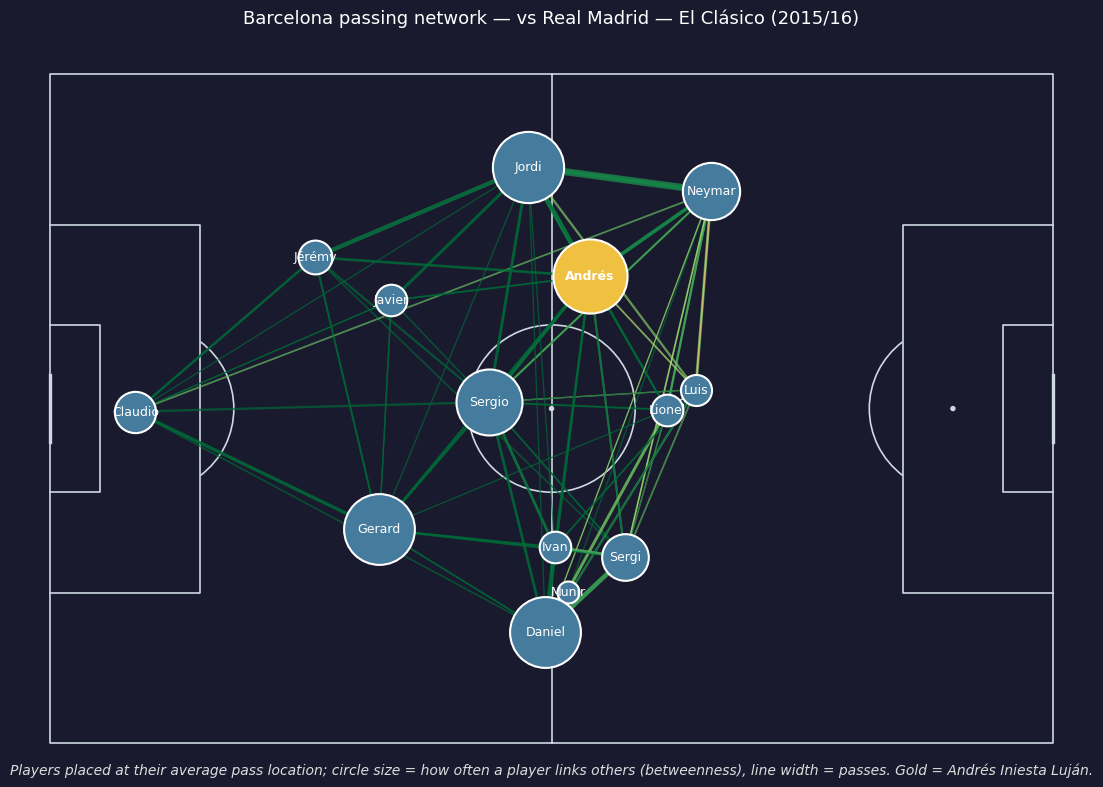

In [2]:
MID = 266424
passes = load_pass_events(MID)
barca = passes[passes['team']=='Barcelona']
G = build_passing_network(barca, 'Barcelona')
pos = compute_node_positions(barca, 'Barcelona')
iniesta = [n for n in G.nodes() if 'Iniesta' in n][0]
viz.plot_passing_network_on_pitch(G, pos, 'Barcelona',
    'vs Real Madrid — El Clásico (2015/16)', highlight_node=iniesta,
    pass_df=barca, save_path=fp('fig_02_passing_network_pitch.png'))
plt.show()

## fig_03 — Resilience bar (El Clásico)

Same match (266424); the three most critical players are Dani Alves, Iniesta and Busquets — the ball-playing-defender + midfield core.

Top 3 critical: ['Daniel Alves da Silva', 'Andrés Iniesta Luján', 'Sergio Busquets i Burgos']


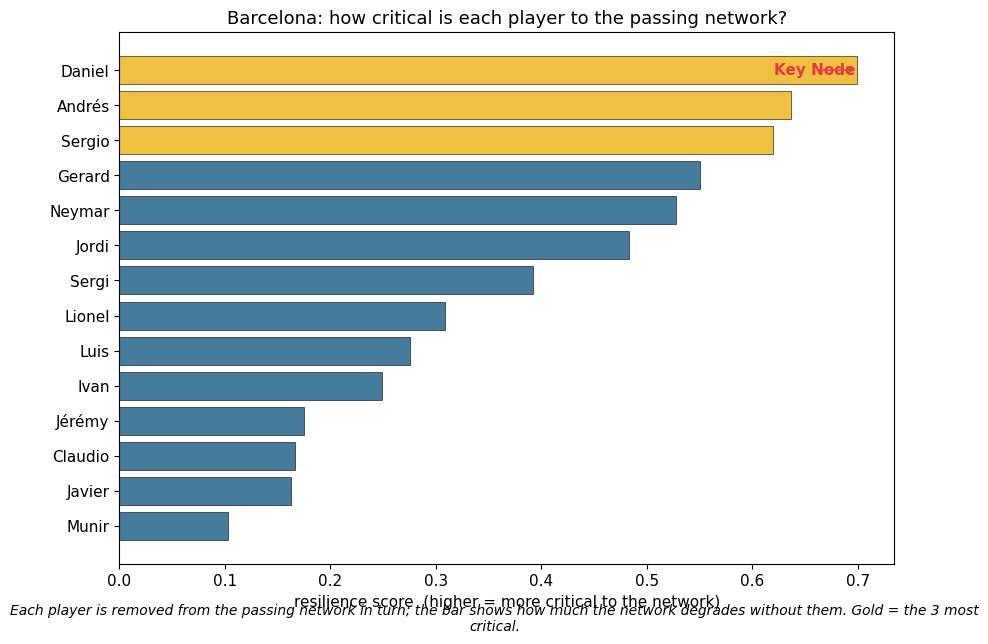

In [3]:
res = compute_resilience(G)
print('Top 3 critical:', res['player'].head(3).tolist())
viz.plot_resilience_bar(res, 'Barcelona',
    save_path=fp('fig_03_resilience_bar.png'))
plt.show()

## fig_03 — Zone-flow heatmap: Barcelona vs Atlético (same match)

Match 266166 (Atlético 1-2 Barcelona) contains both teams, so the two heatmaps are from the exact same game. Red outlines = the defensive→attacking-third bottleneck (min-cut).

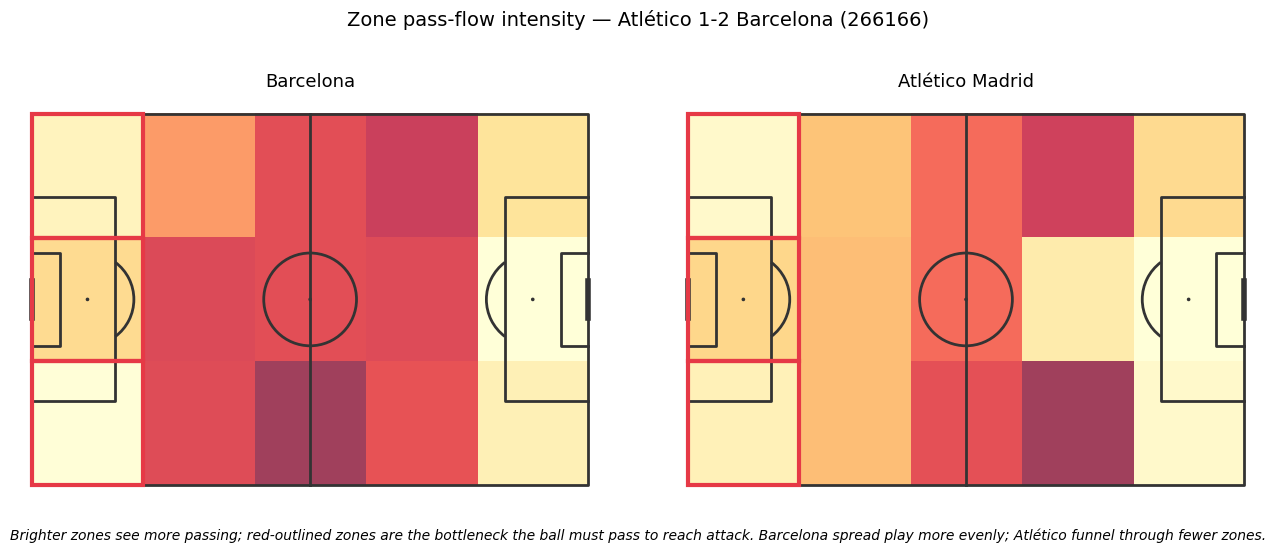

In [4]:
p2 = load_pass_events(266166)
zg_barca = build_zone_graph(p2, 'Barcelona')
zg_atleti = build_zone_graph(p2, 'Atlético Madrid')
from mplsoccer import Pitch
# Let mplsoccer create the figure+axes so the pitches stay landscape.
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='#333333')
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 5))
viz.plot_zone_flow_heatmap(zg_barca, ax=axes[0], title='Barcelona')
viz.plot_zone_flow_heatmap(zg_atleti, ax=axes[1], title='Atlético Madrid')
fig.suptitle('Zone pass-flow intensity — Atlético 1-2 Barcelona (266166)',
             fontsize=14, y=1.02)
fig.text(0.5, -0.04, 'Brighter zones see more passing; red-outlined '
         'zones are the bottleneck the ball must pass to reach attack. '
         'Barcelona spread play more evenly; Atlético funnel through fewer zones.',
         ha='center', style='italic', fontsize=10)
fig.savefig(fp('fig_03_zone_flow_heatmap.png'), dpi=300, bbox_inches='tight')
fig.savefig(fp('fig_03_zone_flow_heatmap.svg'), bbox_inches='tight')
plt.show()

## fig_04 — Dynamic network metrics with detected shifts

Match 265839 (Barcelona), where all detected shifts were validated against goals/substitutions (±3 min).

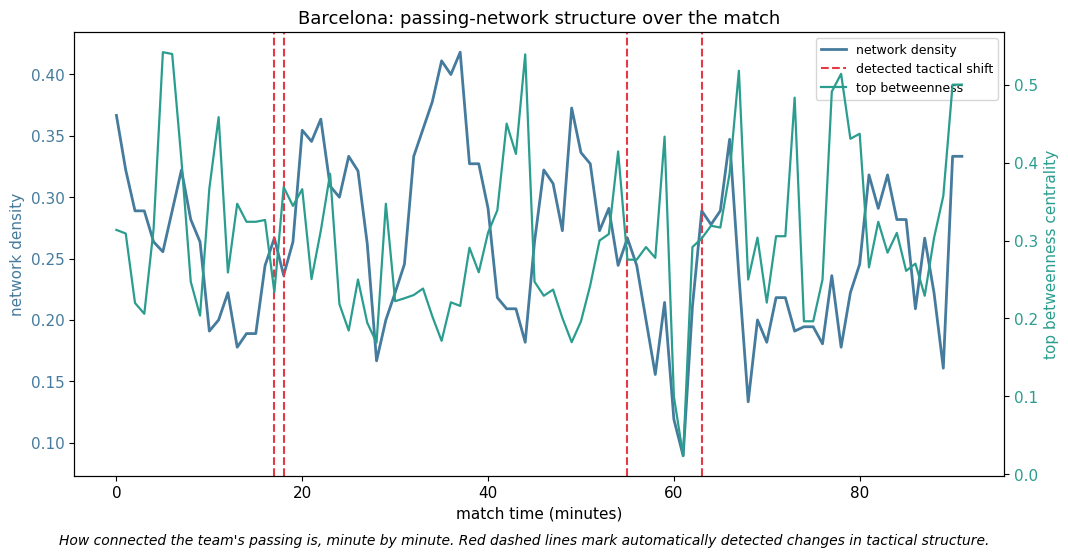

In [5]:
barca_sevilla = load_pass_events(265839)
barca_sevilla = barca_sevilla[barca_sevilla['team']=='Barcelona']
dyn = build_dynamic_network(barca_sevilla, 'Barcelona')
shifts = detect_tactical_shifts(dyn, threshold=2.0)
viz.plot_dynamic_network_metrics(dyn, shifts, 'Barcelona',
    save_path=fp('fig_04_dynamic_metrics.png'))
plt.show()

## fig_03 — Pressure comparison radar (Barcelona, El Clásico, free vs pressed)

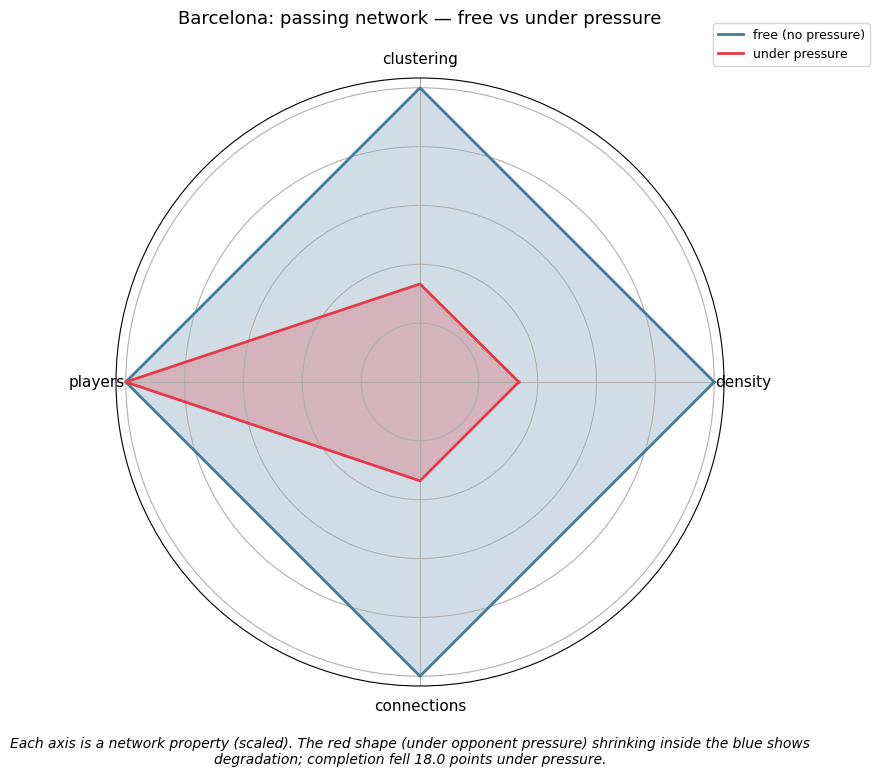

In [6]:
deg = compute_pressure_degradation(barca, 'Barcelona')
viz.plot_pressure_comparison(deg, 'Barcelona',
    save_path=fp('fig_03_pressure_comparison.png'))
plt.show()

## fig_04 — Team-level cluster scatter (PCA)

Teams coloured by their tactical cluster. **Villarreal** is annotated as a mild outlier: their season network metrics (lower density, more direct progression) placed them in the lower-table-direct cluster **C2** despite a respectable league finish — flagged here for transparency rather than hidden.

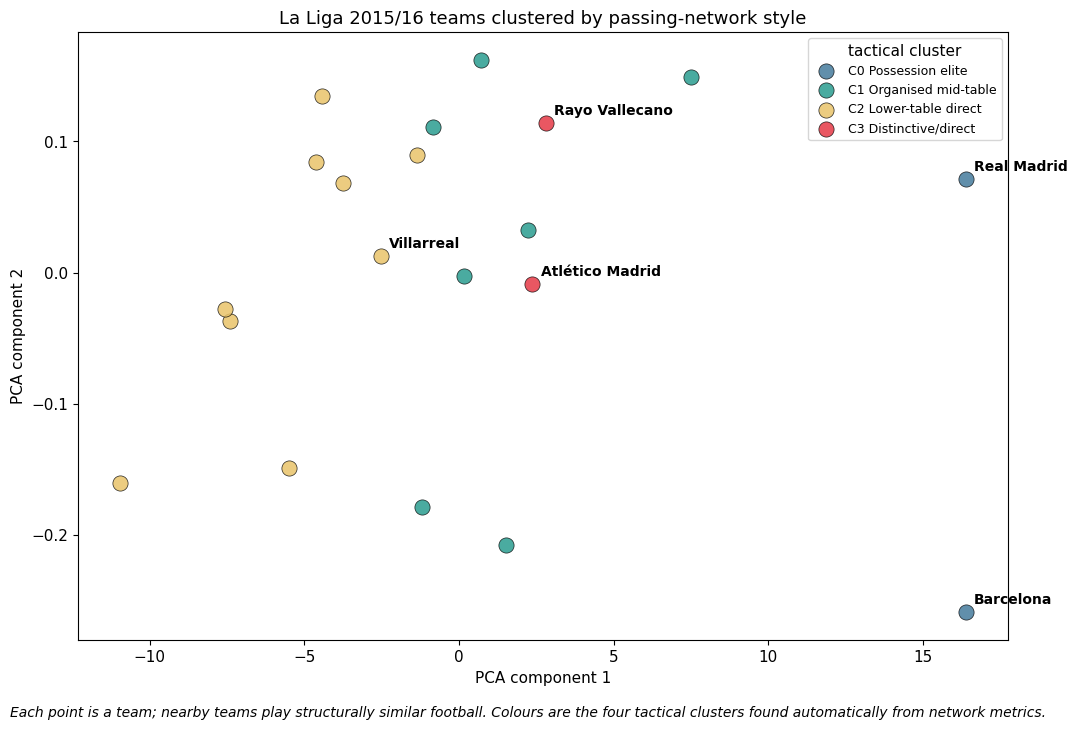

Villarreal cluster: 2 -> C2 Lower-table direct


In [7]:
full = pd.read_parquet(os.path.abspath('../data/processed/feature_matrix.parquet'))
team_feat = full.groupby('team')[FEATURE_COLUMNS].mean()
labels = cluster_teams_by_network(full, 4).set_index('team')['cluster_label']
viz.plot_cluster_scatter(team_feat, labels,
    save_path=fp('fig_04_cluster_scatter.png'))
plt.show()
print('Villarreal cluster:', labels['Villarreal'],
      '->', viz.CLUSTER_NAMES[labels['Villarreal']])

In [8]:
import glob
pngs = sorted(glob.glob(fp('*.png'))); svgs = sorted(glob.glob(fp('*.svg')))
print(f'{len(pngs)} PNG + {len(svgs)} SVG in figures/')
for p in pngs: print(' ', os.path.basename(p))

6 PNG + 6 SVG in figures/
  fig_02_passing_network_pitch.png
  fig_03_pressure_comparison.png
  fig_03_resilience_bar.png
  fig_03_zone_flow_heatmap.png
  fig_04_cluster_scatter.png
  fig_04_dynamic_metrics.png


## Figures produced

All six plot functions executed without error and figures/ holds the PNG + SVG pairs. Ready for the blog post and paper.